# 분석 데이터 전처리

## 데이터 구조와 품질 문제 확인

In [137]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import koreanize_matplotlib

In [114]:
df = pd.read_csv('dataFile/A_공유자전거_대여운영_dirty.csv')
df.head()

,rental_id,station_zone,member_type,weather,temperature_c,humidity_pct,wind_speed_mps,distance_km,ride_duration_min,bike_age_months,late_return
0,R0001,공원,일일권,비,31.5,77.0,5.6,4.11,NaN,28.0,0
1,R0002,도심,월회원,흐림,23.3,74.6,4.6,1.35,11.0,33.0,0
2,R0003,공원,일일권,맑음,22.5,56.3,1.0,1.49,11.6,31.0,0
3,R0004,공원,연회원,흐림,28.6,77.3,2.0,6.73,27.5,21.0,0
4,R0005,공원,월회원,맑음,13.0,46.3,0.8,3.09,17.5,42.0,0


In [115]:
df.shape

(652, 11)

In [116]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 652 entries, 0 to 651
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rental_id          652 non-null    str    
 1   station_zone       652 non-null    str    
 2   member_type        629 non-null    str    
 3   weather            635 non-null    str    
 4   temperature_c      652 non-null    float64
 5   humidity_pct       627 non-null    float64
 6   wind_speed_mps     652 non-null    float64
 7   distance_km        652 non-null    float64
 8   ride_duration_min  631 non-null    float64
 9   bike_age_months    638 non-null    float64
 10  late_return        652 non-null    int64  
dtypes: float64(6), int64(1), str(4)
memory usage: 56.2 KB


In [117]:
df.describe(include='all')

,rental_id,station_zone,member_type,weather,temperature_c,humidity_pct,wind_speed_mps,distance_km,ride_duration_min,bike_age_months,late_return
count,652,652,629,635,652.000000,627.000000,652.000000,652.000000,631.000000,638.000000,652.000000
unique,644,4,3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,R0019,주거,월회원,맑음,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,2,192,245,375,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,22.854755,62.670175,3.218558,4.318466,22.682092,22.354232,0.050613
std,NaN,NaN,NaN,NaN,6.487134,15.228703,1.392390,5.384499,24.133076,10.928047,0.219375
min,NaN,NaN,NaN,NaN,-19.100000,28.000000,0.200000,0.680000,4.000000,1.000000,0.000000
25%,NaN,NaN,NaN,NaN,19.000000,51.750000,2.200000,2.180000,13.500000,14.000000,0.000000
50%,NaN,NaN,NaN,NaN,22.600000,61.500000,3.200000,3.280000,18.600000,22.000000,0.000000
75%,NaN,NaN,NaN,NaN,27.225000,72.100000,4.200000,4.910000,24.900000,29.000000,0.000000


In [118]:
null_cnt = df.isna().sum()
missing_ratio = df.isna().mean()
null_cnt

rental_id             0
station_zone          0
member_type          23
weather              17
temperature_c         0
humidity_pct         25
wind_speed_mps        0
distance_km           0
ride_duration_min    21
bike_age_months      14
late_return           0
dtype: int64

In [119]:
null_df = pd.DataFrame({
    'missing_count':null_cnt,
    'missing_ratio':missing_ratio
})
null_df

,missing_count,missing_ratio
rental_id,0,0.000000
station_zone,0,0.000000
member_type,23,0.035276
weather,17,0.026074
temperature_c,0,0.000000
humidity_pct,25,0.038344
wind_speed_mps,0,0.000000
distance_km,0,0.000000
ride_duration_min,21,0.032209
bike_age_months,14,0.021472


In [120]:
df.duplicated().sum()

np.int64(6)

In [121]:
df.duplicated(subset=['rental_id']).sum()

np.int64(8)

## 중복과 결측치 처리

In [122]:
df_drop_dup = df.drop_duplicates().copy()
df_drop_dup

,rental_id,station_zone,member_type,weather,temperature_c,humidity_pct,wind_speed_mps,distance_km,ride_duration_min,bike_age_months,late_return
0,R0001,공원,일일권,비,31.5,77.0,5.6,4.11,NaN,28.0,0
1,R0002,도심,월회원,흐림,23.3,74.6,4.6,1.35,11.0,33.0,0
2,R0003,공원,일일권,맑음,22.5,56.3,1.0,1.49,11.6,31.0,0
3,R0004,공원,연회원,흐림,28.6,77.3,2.0,6.73,27.5,21.0,0
4,R0005,공원,월회원,맑음,13.0,46.3,0.8,3.09,17.5,42.0,0
...,...,...,...,...,...,...,...,...,...,...,...
641,R0642,대학가,연회원,흐림,22.4,80.8,5.5,1.53,8.6,NaN,0
642,R0643,주거,월회원,맑음,31.6,64.0,3.4,3.08,17.9,27.0,0
643,R0644,대학가,일일권,맑음,20.3,56.5,3.3,4.05,23.7,1.0,0
650,R0064,대학가,일일권,흐림,29.4,76.3,1.6,1.44,205.7,37.0,0


In [123]:
df_drop_dup[df_drop_dup.duplicated(subset=['rental_id'], keep=False)].sort_values('rental_id')

,rental_id,station_zone,member_type,weather,temperature_c,humidity_pct,wind_speed_mps,distance_km,ride_duration_min,bike_age_months,late_return
63,R0064,대학가,일일권,흐림,29.0,72.4,1.6,1.44,205.7,37.0,0
650,R0064,대학가,일일권,흐림,29.4,76.3,1.6,1.44,205.7,37.0,0
136,R0137,주거,일일권,비,19.3,70.7,3.7,4.13,27.0,16.0,0
651,R0137,주거,일일권,비,19.8,73.8,3.7,4.13,27.0,16.0,0


In [124]:
df_drop_dup = df_drop_dup.drop_duplicates(subset=['rental_id'], keep='last')
df_drop_dup

,rental_id,station_zone,member_type,weather,temperature_c,humidity_pct,wind_speed_mps,distance_km,ride_duration_min,bike_age_months,late_return
0,R0001,공원,일일권,비,31.5,77.0,5.6,4.11,NaN,28.0,0
1,R0002,도심,월회원,흐림,23.3,74.6,4.6,1.35,11.0,33.0,0
2,R0003,공원,일일권,맑음,22.5,56.3,1.0,1.49,11.6,31.0,0
3,R0004,공원,연회원,흐림,28.6,77.3,2.0,6.73,27.5,21.0,0
4,R0005,공원,월회원,맑음,13.0,46.3,0.8,3.09,17.5,42.0,0
...,...,...,...,...,...,...,...,...,...,...,...
641,R0642,대학가,연회원,흐림,22.4,80.8,5.5,1.53,8.6,NaN,0
642,R0643,주거,월회원,맑음,31.6,64.0,3.4,3.08,17.9,27.0,0
643,R0644,대학가,일일권,맑음,20.3,56.5,3.3,4.05,23.7,1.0,0
650,R0064,대학가,일일권,흐림,29.4,76.3,1.6,1.44,205.7,37.0,0


In [125]:
num_cols_na = df_drop_dup.select_dtypes(include='number').columns
num_cols_na = num_cols_na[df_drop_dup[num_cols_na].isnull().any()]
num_cols_na

Index(['humidity_pct', 'ride_duration_min', 'bike_age_months'], dtype='str')

In [126]:
cat_cols_na = df_drop_dup.select_dtypes(exclude='number').columns
cat_cols_na = cat_cols_na[df_drop_dup[cat_cols_na].isnull().any()]
cat_cols_na

Index(['member_type', 'weather'], dtype='str')

In [127]:
for c in cat_cols_na:
    df_drop_dup[c] = df_drop_dup[c].fillna("미상")

In [128]:
for c in num_cols_na:
    df_drop_dup[c] = df_drop_dup[c].fillna(df_drop_dup[c].median())

In [129]:
df_drop_dup.isnull().sum()

rental_id            0
station_zone         0
member_type          0
weather              0
temperature_c        0
humidity_pct         0
wind_speed_mps       0
distance_km          0
ride_duration_min    0
bike_age_months      0
late_return          0
dtype: int64

## 이상치 탐지와 처리 전략

<Axes: >

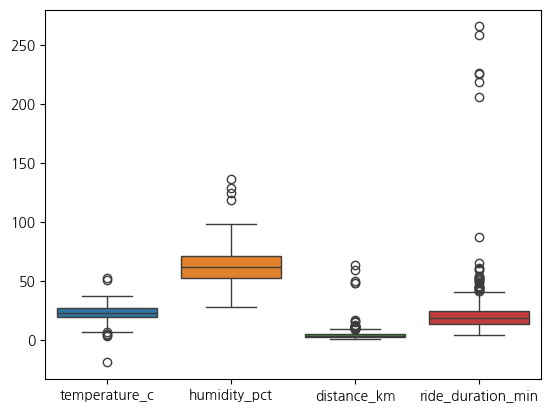

In [130]:
boxplot_cols = ['temperature_c', 'humidity_pct', 'distance_km', 'ride_duration_min']
sns.boxplot(data=df_drop_dup[boxplot_cols])

In [131]:
# temperature_c
q1_t = df_drop_dup['temperature_c'].quantile(.25)
q3_t = df_drop_dup['temperature_c'].quantile(.75)

iqr_t = q3_t - q1_t

lower_t = q1_t - 1.5 * iqr_t
upper_t = q3_t + 1.5 * iqr_t

n_outlier_t = ((df_drop_dup['temperature_c'] < lower_t) | (df_drop_dup['temperature_c'] > upper_t)).sum()
n_outlier_t

np.int64(7)

In [132]:
# humidity_pct
q1_h = df_drop_dup['humidity_pct'].quantile(.25)
q3_h = df_drop_dup['humidity_pct'].quantile(.75)

iqr_h = q3_h - q1_h

lower_h = q1_h - 1.5 * iqr_h
upper_h = q3_h + 1.5 * iqr_h

n_outlier_h = ((df_drop_dup['humidity_pct'] < lower_h) | (df_drop_dup['humidity_pct'] > upper_h)).sum()
n_outlier_h

np.int64(4)

In [133]:
# distance_km
q1_d = df_drop_dup['distance_km'].quantile(.25)
q3_d = df_drop_dup['distance_km'].quantile(.75)

iqr_d = q3_d - q1_d

lower_d = q1_d - 1.5 * iqr_d
upper_d = q3_d + 1.5 * iqr_d

n_outlier_d = ((df_drop_dup['distance_km'] < lower_d) | (df_drop_dup['distance_km'] > upper_d)).sum()
n_outlier_d

np.int64(33)

In [134]:
# ride_duration_min
q1_r = df_drop_dup['ride_duration_min'].quantile(.25)
q3_r = df_drop_dup['ride_duration_min'].quantile(.75)

iqr_r = q3_r - q1_r

lower_r = q1_r - 1.5 * iqr_r
upper_r = q3_r + 1.5 * iqr_r

n_outlier_r = ((df_drop_dup['ride_duration_min'] < lower_r) | (df_drop_dup['ride_duration_min'] > upper_r)).sum()
n_outlier_r

np.int64(31)

In [135]:
df_drop_dup['temperature_c'] = df_drop_dup['temperature_c'].clip(lower_t, upper_t)
df_drop_dup['temperature_c'].describe()

count    644.000000
mean      22.851708
std        6.145733
min        6.700000
25%       19.000000
50%       22.600000
75%       27.200000
max       39.500000
Name: temperature_c, dtype: float64

## 파생변수, 인코딩, 스케일링

In [136]:
df_drop_dup['avg_speed_kmh'] = df_drop_dup['distance_km'] / (df_drop_dup['ride_duration_min'] / 60)
df_drop_dup['avg_speed_kmh'].describe()

count    644.000000
mean      12.866638
std       22.046862
min        0.420029
25%        9.267358
50%       11.093866
75%       12.867059
max      360.800000
Name: avg_speed_kmh, dtype: float64

In [139]:
np.isfinite(df_drop_dup["avg_speed_kmh"]).all()

np.True_

In [140]:
df_drop_dup["speed_outlier"] = df_drop_dup["avg_speed_kmh"].gt(60).astype("int")
df_drop_dup["speed_outlier"].sum()

np.int64(5)

In [141]:
df_drop_dup['bad_weather'] = df_drop_dup['weather'].map(lambda x: 1 if x=='비' else 0)
df_drop_dup.head()

,rental_id,station_zone,member_type,weather,temperature_c,humidity_pct,wind_speed_mps,distance_km,ride_duration_min,bike_age_months,late_return,avg_speed_kmh,speed_outlier,bad_weather
0,R0001,공원,일일권,비,31.5,77.0,5.6,4.11,18.6,28.0,0,13.258065,0,1
1,R0002,도심,월회원,흐림,23.3,74.6,4.6,1.35,11.0,33.0,0,7.363636,0,0
2,R0003,공원,일일권,맑음,22.5,56.3,1.0,1.49,11.6,31.0,0,7.706897,0,0
3,R0004,공원,연회원,흐림,28.6,77.3,2.0,6.73,27.5,21.0,0,14.683636,0,0
4,R0005,공원,월회원,맑음,13.0,46.3,0.8,3.09,17.5,42.0,0,10.594286,0,0


In [142]:
df2 = pd.get_dummies(data=df_drop_dup, columns=['station_zone', 'member_type', 'weather'])
df2.head()

,rental_id,temperature_c,humidity_pct,wind_speed_mps,distance_km,ride_duration_min,bike_age_months,late_return,avg_speed_kmh,speed_outlier,bad_weather,station_zone_공원,station_zone_대학가,station_zone_도심,station_zone_주거,member_type_미상,member_type_연회원,member_type_월회원,member_type_일일권,weather_맑음,weather_미상,weather_비,weather_흐림
0,R0001,31.5,77.0,5.6,4.11,18.6,28.0,0,13.258065,0,1,True,False,False,False,False,False,False,True,False,False,True,False
1,R0002,23.3,74.6,4.6,1.35,11.0,33.0,0,7.363636,0,0,False,False,True,False,False,False,True,False,False,False,False,True
2,R0003,22.5,56.3,1.0,1.49,11.6,31.0,0,7.706897,0,0,True,False,False,False,False,False,False,True,True,False,False,False
3,R0004,28.6,77.3,2.0,6.73,27.5,21.0,0,14.683636,0,0,True,False,False,False,False,True,False,False,False,False,False,True
4,R0005,13.0,46.3,0.8,3.09,17.5,42.0,0,10.594286,0,0,True,False,False,False,False,False,True,False,True,False,False,False


In [143]:
scaler = StandardScaler()
scale_cols = ['temperature_c', 'humidity_pct', 'wind_speed_mps', 'distance_km', 'ride_duration_min', 'bike_age_months', 'avg_speed_kmh']
df2[scale_cols].describe().loc[['mean', 'std']]

,temperature_c,humidity_pct,wind_speed_mps,distance_km,ride_duration_min,bike_age_months,avg_speed_kmh
mean,22.851708,62.636801,3.225621,4.245885,22.292702,22.352484,12.866638
std,6.145733,14.954426,1.390697,4.969480,22.767060,10.814927,22.046862


In [144]:
df2[scale_cols] = scaler.fit_transform(df2[scale_cols])
df2[scale_cols].describe().loc[['mean', 'std']]

,temperature_c,humidity_pct,wind_speed_mps,distance_km,ride_duration_min,bike_age_months,avg_speed_kmh
mean,-1.213660e-16,-2.758318e-17,-3.116899e-16,-8.688702e-17,4.413309e-17,6.068300e-17,1.930823e-17
std,1.000777e+00,1.000777e+00,1.000777e+00,1.000777e+00,1.000777e+00,1.000777e+00,1.000777e+00


In [145]:
df2.to_csv('A_공유자전거_cleaned.csv', index=False)

# 탐색적 데이터 분석

## 단변량 분포와 표본 불균형 확인

<Axes: xlabel='ride_duration_min', ylabel='Count'>

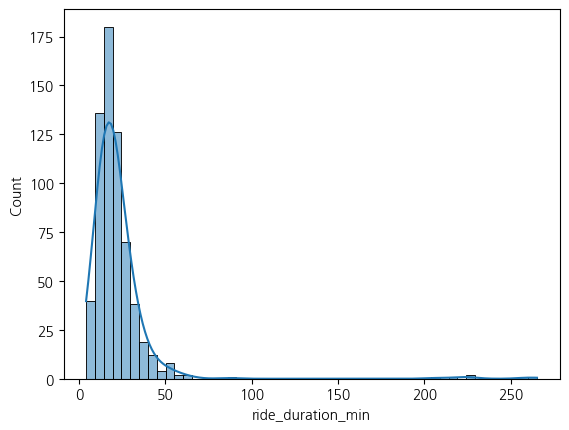

In [146]:
sns.histplot(data=df_drop_dup['ride_duration_min'], kde=True)

<Axes: xlabel='station_zone', ylabel='count'>

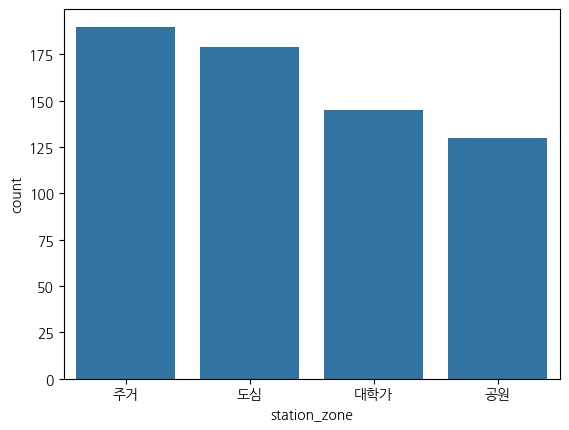

In [147]:
sns.countplot(data=df_drop_dup, x='station_zone', order=df_drop_dup['station_zone'].value_counts().index)

In [149]:
late_summary = df_drop_dup['late_return'].value_counts().to_frame('count')
late_summary['ratio'] = df['late_return'].value_counts(normalize=True)
late_summary

,count,ratio
late_return,,
0,613,0.949387
1,31,0.050613


## 수치형 변수 관계 분석

<Axes: >

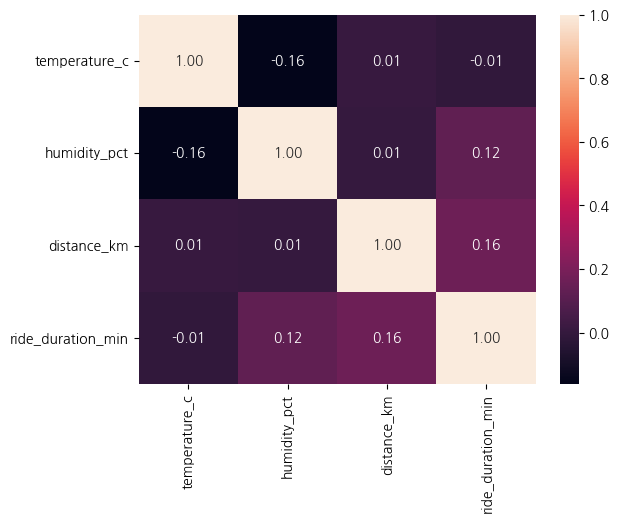

In [150]:
corr = df_drop_dup[['temperature_c', 'humidity_pct', 'distance_km', 'ride_duration_min']].corr()
sns.heatmap(corr, annot=True, fmt='.2f')

In [151]:
pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
top_pair = pairs.abs().idxmax()
top_pair, corr.loc[top_pair]

(('distance_km', 'ride_duration_min'), np.float64(0.1643210976875232))

<Axes: xlabel='distance_km', ylabel='ride_duration_min'>

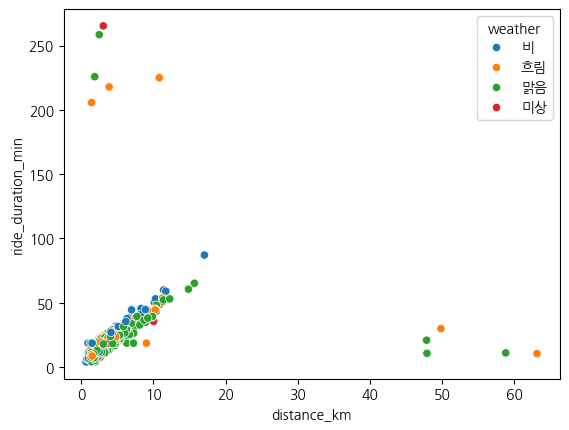

In [152]:
sns.scatterplot(data=df_drop_dup, x='distance_km', y='ride_duration_min', hue='weather')

##  그룹 비교 분석

<Axes: xlabel='member_type', ylabel='ride_duration_min'>

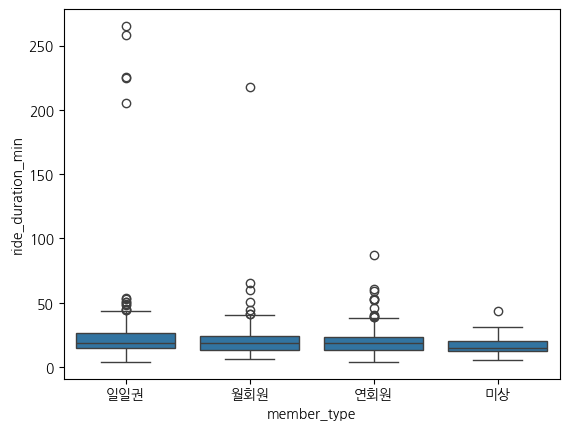

In [153]:
sns.boxplot(data=df_drop_dup, x='member_type', y='ride_duration_min')

In [154]:
df_drop_dup.groupby("weather")[["distance_km", "ride_duration_min"]].mean()

,distance_km,ride_duration_min
weather,,
맑음,4.234367,20.762803
미상,3.216471,32.000000
비,4.145376,23.815054
흐림,4.436810,23.893865


In [155]:
pd.crosstab(
    index=df_drop_dup['station_zone'], 
    columns=df_drop_dup['late_return'], 
    normalize='index'
)

late_return,0,1
station_zone,,
공원,0.969231,0.030769
대학가,0.965517,0.034483
도심,0.944134,0.055866
주거,0.936842,0.063158
